In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime


In [2]:
sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))

from src.quantum_hrp import average_density_matrix, compute_distance_matrix
from src.hrp_ordering import hrp_order_from_distance, hrp_order_from_correlation
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

In [3]:
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
features = np.load("../../data/features.npy")

In [4]:
print("returns:", returns.shape, returns.index.min(), returns.index.max())
print("features:", features.shape)
print("features.npy mtime:", datetime.datetime.fromtimestamp(os.path.getmtime("../../data/features.npy")))

returns: (616, 169) 2021-11-11 00:00:00 2024-12-31 00:00:00
features: (169, 616, 6)
features.npy mtime: 2025-12-30 23:26:16.259668


In [5]:
# Use the same horizon for returns and features
T_common = min(len(returns), features.shape[1])

returns_cut = returns.iloc[-T_common:]
corr = returns_cut.corr()

features_cut = features[:, -T_common:, :]

print("T_common:", T_common)
print("returns_cut:", returns_cut.shape, returns_cut.index.min(), returns_cut.index.max())
print("features_cut:", features_cut.shape)

T_common: 616
returns_cut: (616, 169) 2021-11-11 00:00:00 2024-12-31 00:00:00
features_cut: (169, 616, 6)


In [6]:
# Classical HRP
order_classical = hrp_order_from_correlation(corr)
corr_classical = corr.iloc[order_classical, :].iloc[:, order_classical]

# Quantum HRP
alpha = 2.0
N = features_cut.shape[0]
rhos = []

for i in range(N):
    rho = average_density_matrix(features_cut[i], alpha=alpha)
    rhos.append(rho)

D_quantum = compute_distance_matrix(rhos)
order_quantum = hrp_order_from_distance(D_quantum)
corr_quantum = corr.iloc[order_quantum, :].iloc[:, order_quantum]

# Diagnostics (NOW order_quantum exists)
tickers = corr.columns.to_list()
print("Same positions (%):", 100 * np.mean(order_classical == order_quantum))
print("Classical first 20:", [tickers[i] for i in order_classical[:20]])
print("Quantum first 20:", [tickers[i] for i in order_quantum[:20]])
print("Mean abs diff (ordered corr):",
      np.mean(np.abs(corr_classical.values - corr_quantum.values)))

Same positions (%): 1.183431952662722
Classical first 20: ['KRBN', 'VZ', 'T', 'SOYB', 'CORN', 'WEAT', 'TMUS', 'BMY', 'MRNA', 'WBD', 'TGT', 'XRP-USD', 'DOGE-USD', 'BNB-USD', 'SOL-USD', 'AVAX-USD', 'BTC-USD', 'ETH-USD', 'ADA-USD', 'DOT-USD']
Quantum first 20: ['NFLX', 'OXY', 'KRBN', 'CORN', 'REGN', 'INTC', 'XRP-USD', 'WEAT', 'XPEV', 'SCHW', 'WMT', 'DOGE-USD', 'TCEHY', 'PANW', 'XLP', 'BMY', 'TGT', 'FDX', 'BNB-USD', 'BABA']
Mean abs diff (ordered corr): 0.19727405852844387


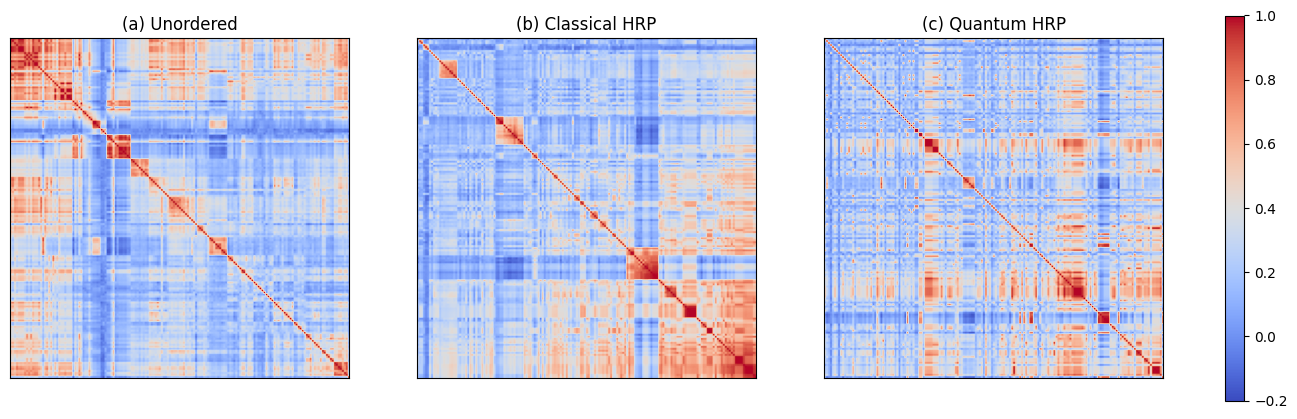

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs[0].imshow(corr, cmap="coolwarm", vmin=-0.2, vmax=1)
axs[0].set_title("(a) Unordered")

axs[1].imshow(corr_classical, cmap="coolwarm", vmin=-0.2, vmax=1)
axs[1].set_title("(b) Classical HRP")

axs[2].imshow(corr_quantum, cmap="coolwarm", vmin=-0.2, vmax=1)
axs[2].set_title("(c) Quantum HRP")

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(axs[0].images[0], ax=axs, fraction=0.02)
plt.savefig("figures/figure3.png", dpi=300)
plt.show()


Abs diff summary:
  mean: 0.19727405852844387
  median: 0.1599066751142436
  max: 1.1037720094147496
  Fro norm: 42.7585582716918


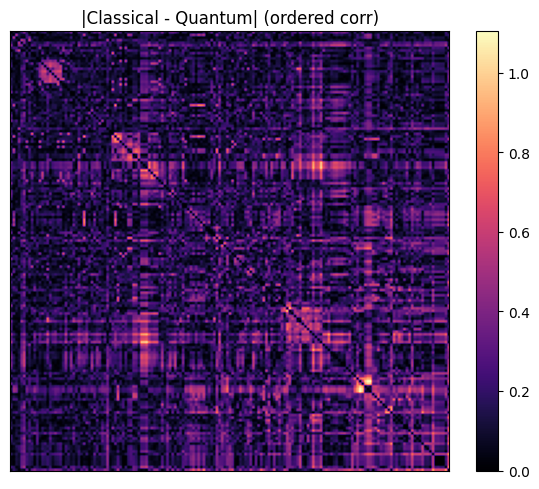

In [8]:
# Debug: quantify/visualize how different the two orderings are
diff = corr_classical.values - corr_quantum.values
abs_diff = np.abs(diff)

print("Abs diff summary:")
print("  mean:", float(abs_diff.mean()))
print("  median:", float(np.median(abs_diff)))
print("  max:", float(abs_diff.max()))
print("  Fro norm:", float(np.linalg.norm(diff, ord='fro')))

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(abs_diff, cmap="magma")
ax.set_title("|Classical - Quantum| (ordered corr)")
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()